<a href="https://colab.research.google.com/github/MiguelGiraldo-Phys/002_EstudiantesAprendizajeEstadistico/blob/patch-1/Laboratorio_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd

df = pd.read_csv('/content/penguins - penguins.csv')

In [2]:
print(df.shape) #(filas,columnas)

(344, 7)


In [4]:
print(df.dtypes)

species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object


In [9]:
print(df.isnull().sum())

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


In [10]:
print(df.duplicated().sum())

0


In [11]:
# Los valores con baja cardinalidad son las variables categoricas, respecto a los  float la mas baja es
# el  flipper_lenght_mm
print(df.nunique())

species                3
island                 3
bill_length_mm       164
bill_depth_mm         80
flipper_length_mm     55
body_mass_g           94
sex                    2
dtype: int64


In [14]:
print(df.describe().round(1))

       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count           342.0          342.0              342.0        342.0
mean             43.9           17.2              200.9       4201.8
std               5.5            2.0               14.1        802.0
min              32.1           13.1              172.0       2700.0
25%              39.2           15.6              190.0       3550.0
50%              44.4           17.3              197.0       4050.0
75%              48.5           18.7              213.0       4750.0
max              59.6           21.5              231.0       6300.0


In [32]:
print(df['species'].value_counts())
print(df['species'].value_counts(normalize=True) * 100)

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64
species
Adelie       44.186047
Gentoo       36.046512
Chinstrap    19.767442
Name: proportion, dtype: float64


In [31]:
print(df['island'].value_counts())
print(df['island'].value_counts(normalize=True) * 100)

island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64
island
Biscoe       48.837209
Dream        36.046512
Torgersen    15.116279
Name: proportion, dtype: float64


In [30]:
print(df['sex'].value_counts())
print(df['sex'].value_counts(normalize=True) * 100)

sex
MALE      168
FEMALE    165
Name: count, dtype: int64
sex
MALE      50.45045
FEMALE    49.54955
Name: proportion, dtype: float64


In [42]:
# Aqui vemos que especies hay en cada isla
tabla = pd.crosstab(df['species'], df['island'])
print(tabla)

# Distribucion de genero por isla
tabla2 = pd.crosstab(df['island'], df['sex'])
print(tabla2)

island     Biscoe  Dream  Torgersen
species                            
Adelie         44     56         52
Chinstrap       0     68          0
Gentoo        124      0          0
sex        FEMALE  MALE
island                 
Biscoe         80    83
Dream          61    62
Torgersen      24    23


In [40]:
df_numerico = df.select_dtypes(include=['number'])
matriz_pearson = df_numerico.corr(method='pearson')

pd.set_option('display.width', 1000)


print(matriz_pearson.round(2))

                   bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
bill_length_mm               1.00          -0.24               0.66         0.60
bill_depth_mm               -0.24           1.00              -0.58        -0.47
flipper_length_mm            0.66          -0.58               1.00         0.87
body_mass_g                  0.60          -0.47               0.87         1.00


In [41]:
matriz_spearman = df_numerico.corr(method='spearman')
pd.set_option('display.width', 1000)
print(matriz_spearman.round(2))

                   bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
bill_length_mm               1.00          -0.22               0.67         0.58
bill_depth_mm               -0.22           1.00              -0.52        -0.43
flipper_length_mm            0.67          -0.52               1.00         0.84
body_mass_g                  0.58          -0.43               0.84         1.00


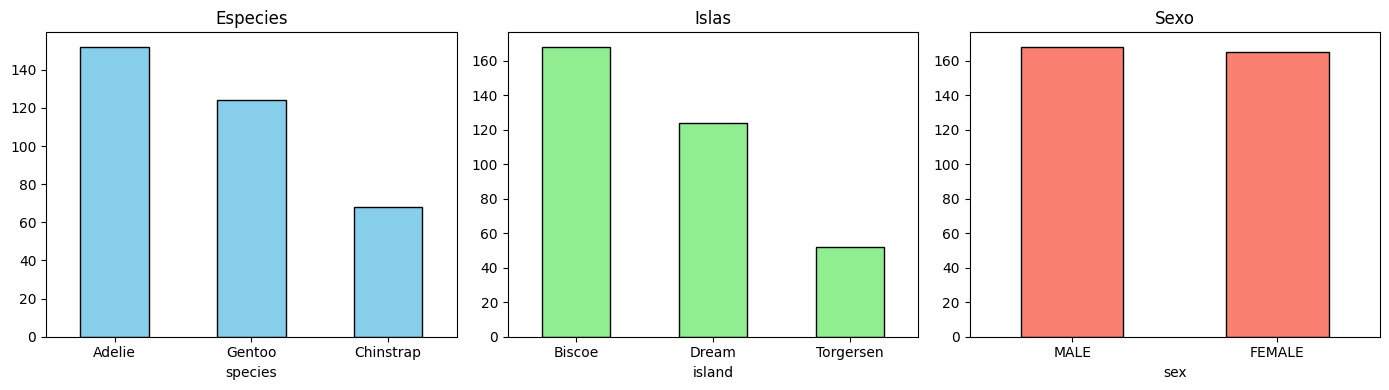

In [2]:
import matplotlib.pyplot as plt


fig, axes = plt.subplots(1, 3, figsize=(14, 4))


df['species'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black', ax=axes[0])
axes[0].set_title('Especies')
axes[0].tick_params(axis='x', rotation=0)

df['island'].value_counts().plot(kind='bar', color='lightgreen', edgecolor='black', ax=axes[1])
axes[1].set_title('Islas')
axes[1].tick_params(axis='x', rotation=0)


df['sex'].value_counts().plot(kind='bar', color='salmon', edgecolor='black', ax=axes[2])
axes[2].set_title('Sexo')
axes[2].tick_params(axis='x', rotation=0)


plt.tight_layout()
plt.show()


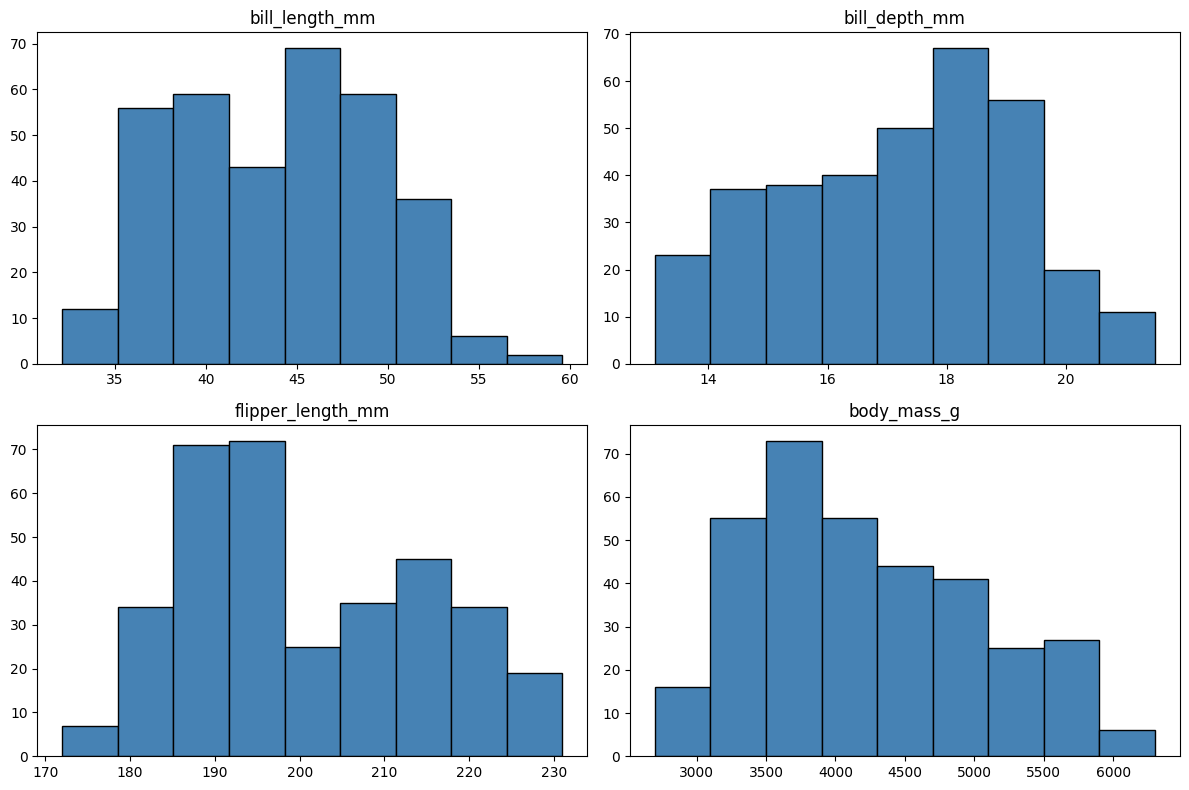

In [8]:
df.hist(bins=9, color='steelblue', edgecolor='black', grid=False, figsize=(12, 8))

plt.tight_layout()
plt.show()

/tmp/ipykernel_596/3428843061.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y='body_mass_g', palette='Set2')


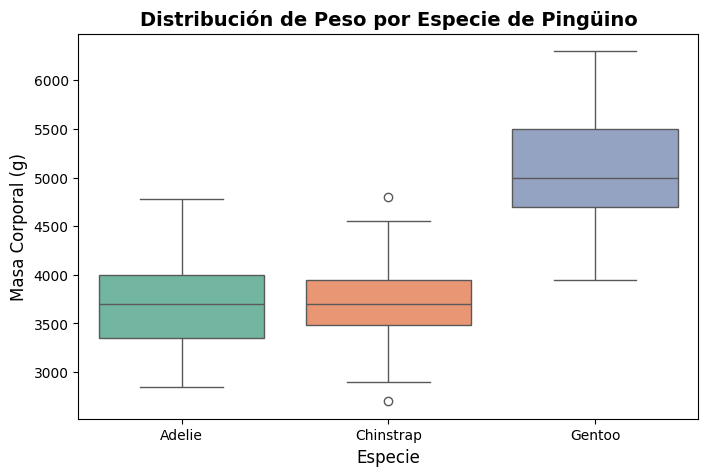

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='species', y='body_mass_g', palette='Set2')

plt.title('Distribución de Peso por Especie de Pingüino', fontsize=14, fontweight='bold')
plt.xlabel('Especie', fontsize=12)
plt.ylabel('Masa Corporal (g)', fontsize=12)

plt.show()


/tmp/ipykernel_596/1785861110.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='island', y='bill_length_mm', palette='Set2')


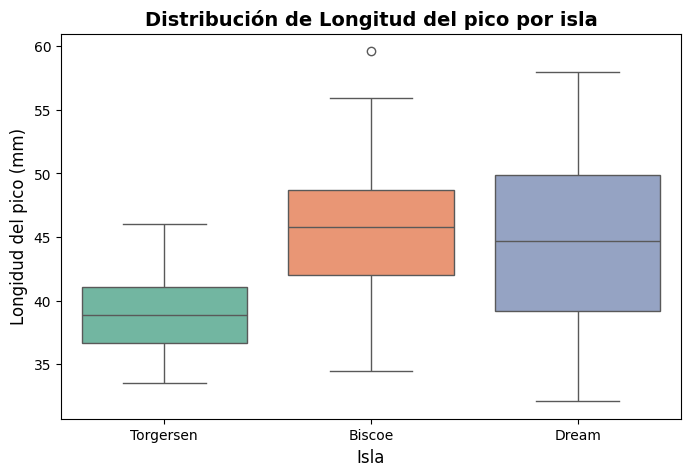

In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='island', y='bill_length_mm', palette='Set2')

plt.title('Distribución de Longitud del pico por isla', fontsize=14, fontweight='bold')
plt.xlabel('Isla', fontsize=12)
plt.ylabel('Longidud del pico (mm)', fontsize=12)

plt.show()


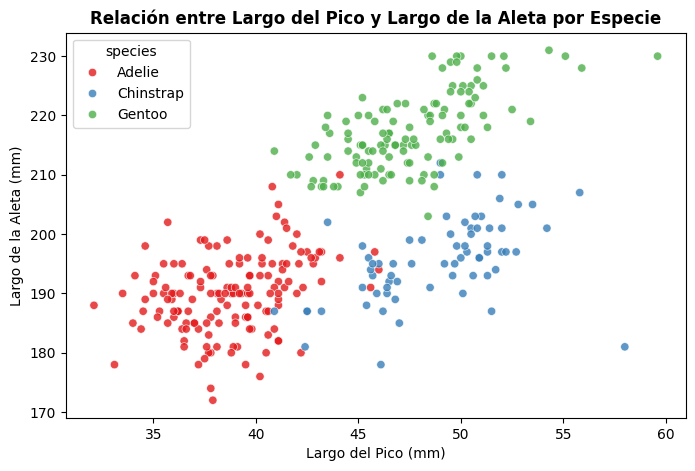

In [17]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='bill_length_mm', y='flipper_length_mm', hue='species', palette='Set1', alpha=0.8)
plt.title('Relación entre Largo del Pico y Largo de la Aleta por Especie', fontsize=12, fontweight='bold')
plt.xlabel('Largo del Pico (mm)')
plt.ylabel('Largo de la Aleta (mm)')
plt.show()


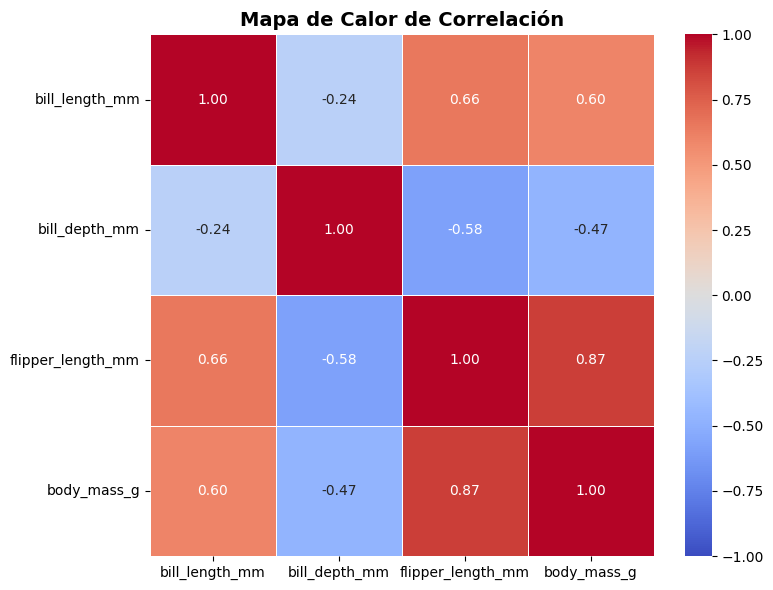

In [18]:
matriz_corr = df.select_dtypes(include=['number']).corr()


plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Mapa de Calor de Correlación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Propuesta de hipotesis
1. El tamaño de la aleta y el peso del pinguino estan relacionados
2. El largo del pico no esta relacionado con su ancho
3. Cada especie de pinguino tiene una longitud media de pico diferente

In [5]:
from scipy import stats


df_limpio = df[['flipper_length_mm', 'body_mass_g']].dropna()

coeficiente, p_valor = stats.pearsonr(df_limpio['flipper_length_mm'], df_limpio['body_mass_g'])

print(f"Coeficiente de correlación de Pearson: {coeficiente:.2f}")
print(f"P-Valor: {p_valor}")


Coeficiente de correlación de Pearson: 0.87
P-Valor: 4.3706809630004724e-107


El coeficiente de correlacion es cercano a uno, por tanto ambas cantidades estan correlacionadas y como el P-value es muy cercano a cero rechazamos la hipotesis nula y concluimos que existe una relacion entre el tamaño de la aleta y el peso del pinguino

In [10]:
df_limpio_pico = df[['bill_depth_mm', 'bill_length_mm']].dropna()
coeficiente, p_valor = stats.pearsonr(df_limpio_pico['bill_depth_mm'], df_limpio_pico['bill_length_mm'])

print(f"Coeficiente de correlación de Pearson: {coeficiente:.2f}")
print(f"P-Valor: {p_valor}")

Coeficiente de correlación de Pearson: -0.24
P-Valor: 1.1196621961373343e-05


El coeficiente de relacion esta lejos de uno, por tanto podemos decir que estas cantidades estan ligeramnete antirelacionadas y como el P-value el cercano a cero validamos la hipotesis nula y consluimos que para este conjunto de datos ancho del pico esta relacionado con su largo

In [11]:

df_limpio = df[['species', 'bill_length_mm']].dropna()
grupos = [subset['bill_length_mm'].values for name, subset in df_limpio.groupby('species')]

# Anova
f_stat, p_valor = stats.f_oneway(*grupos)

print(f"Estadístico F: {f_stat:.2f}")
print(f"P-Valor: {p_valor}")

Estadístico F: 410.60
P-Valor: 2.6946137388895484e-91


El P-value es muy cercanoa cero, por tanto rechazamos la hipotesis nula y concluimos que existe una media diferente de la longitud del pico para cada una de las especies de este conjunto de datos

#Conclusiones

## Hallazgos descriptivos

1. De la muestra de pinguinos 44% son de la especie Adelie, 36% Gentoo y 20% Chinstrap, de los cuelaes 49% habita en Biscue, 36% en Dream y 15% en Torsenguen. La poblacion de pinguinos esta conformada por un aproximadamente de 50% de cada genero y esta tendencia se mantiene en cada uno de los territorios. Mediente la tabla cruzada vemos que la distribucion de especies no es homogenea; en la isla Biscue habitan las especies Adelie y Gentoo, mientras que en Dream habita Adelie y Chinstrap, finalmente en Torsenguen solo habita Gentoo

2. Se observa en la matriz de Pearson que la longitud de la aleta tienen una relacion positiva muy alta con el peso del pinguino, asi como una relacion positiva media con el con el largo del pico.

3. Se observa  en la matriz de Pearson una relacion negativa media del ancho del pico con el largo de la aleta y la masa del pinguino, es decir los pinguinos con picos mas gruesos son mas ligeros y tienen las aletas mas cortas


## Patrones visules

1. del diagrama de barras observamos que las mayor cantidad de pinguinos son Adelie, luego Gentoo y por ultimo Chinstrap. De estos la mayor contidad habita en Biscue, Dream y Torsenguen. la distribucion de genero es casi igual.

2. Del histograma se observan que la longitud del pico sigue una distribucion normal, el pico ancho del pico sigue una distribucion normal sesgada hacia la izquierda, para la longitud de la aleta y la masa se observa una distribucion normal sesgada a derechas. La logitud del pico y la longitud de la aleta, muestras dos picos diferenciables, asi que se podria argumentar que siguen una distribucion Bimodal

3. De los Boxplot se evidencia que la media pinguinos Gentoo son mas pesados y los pinguinos de la isla Torgensen tienen un pico ligeramnete mas corto que en las demas islas.

4. En el grafico de dispersion se observa que existe una relacion entre el largo del pico y el largo de la aleta y se diferencia de forma explicita la que cada especie de pinguino tiene una longitud de pico y largo de aleleta claramente diferenciados en el diagrama.

5. Finalmente la matriz de correlacion evidencia graficamente lo que se dijo en el punto 2 del apartado anterior, verificando la relacion positiva entre peso y el largo de la aleta y el pico y la relacion negativa media entre el ancho, el largo de la aleta y la masa.


## Proximas hipotesis a probar

1. Existe una relacion entre la masa y la ubicacion geografica de los pinguinos

2. La media del ancho de los picos de Bandoo es mayor que los de las otras especies

3. Puede afirmar que la media del ancho del pico varia segun cada especie

## Preguntas para un investigador

1. Estadisticamnete se evidencia una relacion entre el largo y el ancho del pico ¿Existe una relacion de causalidad?

2. Hay una especie de pinguinos que solo habita una isla ¿estos individuos han desarrollado caracteristicas fisicas diferenciadoras debido al aislamiento?

3. ¿Son las islas con mayor poblacion de pinguinos mas extensas o existen
caracteristicas propias de la isla que aumenten la poblacion de pinguinos?

4. ¿Son la distribucion del la longitud del pico y el ala Bimodales? ¿A que se debe este comportamiento?

5. ¿Puede asociar la masa del pinguno con mayor cantidad de alimento disponible en su habitad?